In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import gzip
import shutil
import numpy as np

M_band_samples = {4.4484 : 0.010919, 4.6 : 0.81075, 4.708 : 0.840764, 4.8828 : 0.90181, 5.0454 : 0.79153, 5.11247 : 0.86137, 5.27426 : 0.010345}
def trapezoid_rule(x1, x2, y1, y2):
    ''' Calculates the area of the trapezoid made by two points.
    Parameters
    ----------
    x1, x2 : float
        The left and right x positions
    y1, y2 : float
        The left and right y positions
    Returns
    -------
    float
        The area of the trapezoid in units of x*y
    '''
    return 0.5 * abs(x2 - x1) * (y1 + y2)
with gzip.open('data_th/Temperature.fits.gz', 'rb') as f_in:
    with open('data_th/Temperature.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

In [6]:
for wavelength in M_band_samples.keys():
    with gzip.open(f'data_{wavelength}/RT.fits.gz', 'rb') as f_in:
        with open(f'data_{wavelength}/RT.fits', 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

4.4484 brightness = 3.6834785221984134e-11
4.6 brightness = 3.956632244062064e-11
4.708 brightness = 4.129482172876564e-11
4.8828 brightness = 4.3443467573345274e-11
5.0454 brightness = 4.531153924292042e-11
5.11247 brightness = 4.5973169715551876e-11
5.27426 brightness = 4.739774545070574e-11
Integrated brightness over band = 4.300907199827897e-11


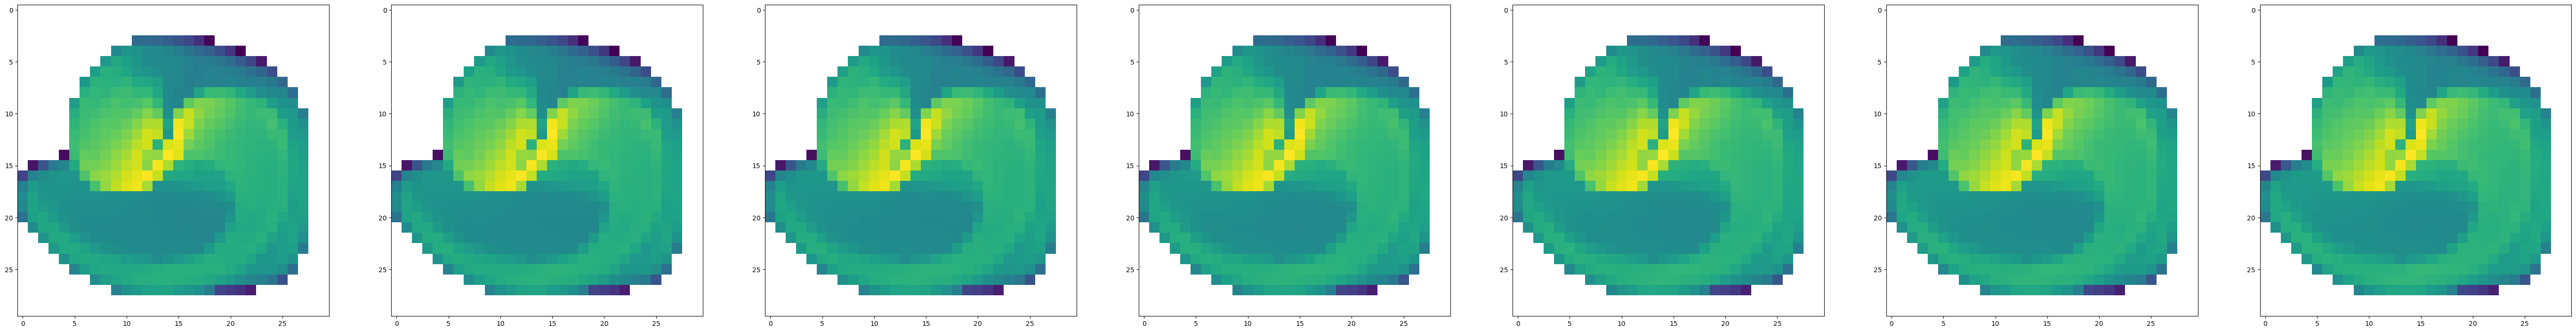

In [11]:
wavelengths = list(M_band_samples.keys())
fig, axes = plt.subplots(figsize=(len(wavelengths) * 10, 10), nrows=1, ncols=len(wavelengths))

running_flux = 0
running_transmittance = 0

for i, wavelength in enumerate(wavelengths):
    hdul = fits.open(f"data_{wavelength}/RT.fits")
    # hdul.info()
    
    data = hdul[0].data[0][0][0]
    
    axes[i].imshow(data[::-1, :], cmap='viridis', norm='log')

    integrated_flux = np.sum(data)

    print(f'{wavelength} brightness = {integrated_flux}')

    if i > 0:
        running_flux += trapezoid_rule(wavelengths[i - 1], wavelength, old_integrated_flux * M_band_samples[wavelengths[i - 1]], 
                                  integrated_flux * M_band_samples[wavelength])
        running_transmittance += trapezoid_rule(wavelengths[i - 1], wavelength, M_band_samples[wavelengths[i - 1]], M_band_samples[wavelength])
        
    old_integrated_flux = integrated_flux

fig.savefig('image.png', dpi=400)

print(f'Integrated brightness over band = {running_flux / running_transmittance}')



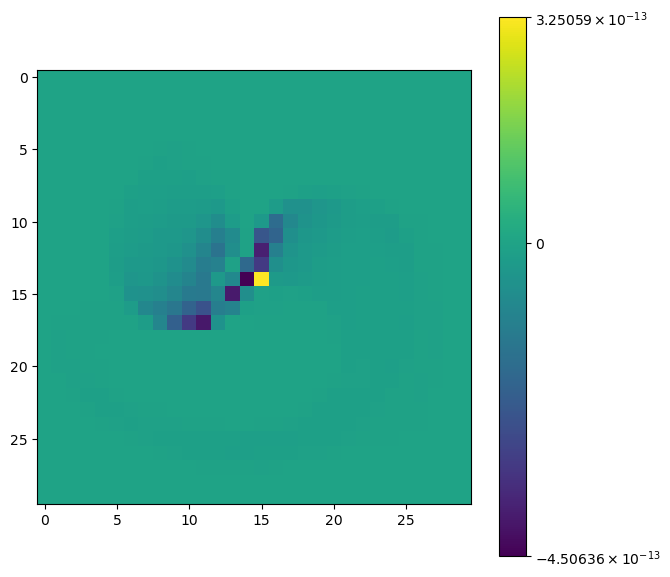

In [20]:
fig, ax = plt.subplots(figsize=(7, 7))

hdul_lowest = fits.open(f"data_{wavelengths[0]}/RT.fits")
data_lowest = hdul_lowest[0].data[0][0][0]

hdul_highest = fits.open(f"data_{wavelengths[-1]}/RT.fits")
data_highest = hdul_highest[0].data[0][0][0]

img = ax.imshow(data_lowest[::-1, :] - data_highest[::-1, :], cmap='viridis', norm='symlog')
fig.colorbar(img)


In the above, positive cells show higher flux at a lower wavelength (i.e. seeing more from the stars) and negative cells show higher flux at high wavelength (i.e. more dust emission)

Filename: data_th/Temperature.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (102398,)   float32   


(array([2.000e+01, 1.020e+02, 5.240e+02, 2.253e+03, 5.369e+03, 7.357e+03,
        6.547e+03, 5.795e+03, 4.922e+03, 5.132e+03, 4.392e+03, 4.614e+03,
        4.126e+03, 2.857e+03, 2.910e+03, 3.383e+03, 3.429e+03, 3.558e+03,
        3.212e+03, 2.676e+03, 2.252e+03, 2.097e+03, 2.006e+03, 1.996e+03,
        1.901e+03, 1.778e+03, 1.711e+03, 1.671e+03, 1.502e+03, 1.485e+03,
        1.348e+03, 1.287e+03, 1.204e+03, 1.163e+03, 1.112e+03, 1.054e+03,
        1.041e+03, 1.013e+03, 9.290e+02, 5.180e+02, 1.380e+02, 1.100e+01,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

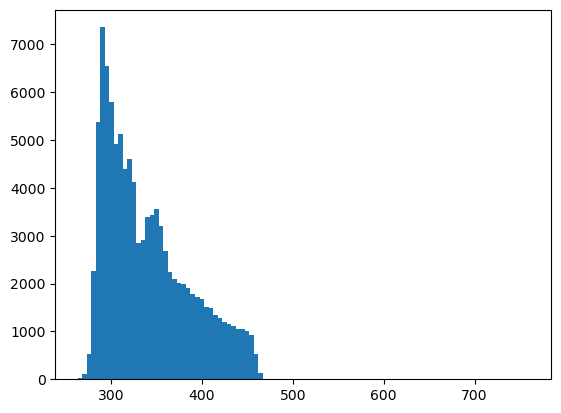

In [12]:
temps = fits.open("data_th/Temperature.fits")
temps.info()

temp_data = temps[0].data

fig, ax = plt.subplots()
ax.hist(temp_data, bins=100)

In [13]:
raw_densities = fits.open("apep1shell.fits")
raw_densities.info()

masses = raw_densities[0].data
weights = masses / max(masses)

particles = raw_densities[1].data
print(particles.shape)

Filename: apep1shell.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   (102398,)   float64   
  1                1 ImageHDU         7   (3, 102398)   float64   
(102398, 3)


/tmp/ipykernel_1037095/798996632.py:11: RuntimeWarning: invalid value encountered in divide
  H /= H_norm


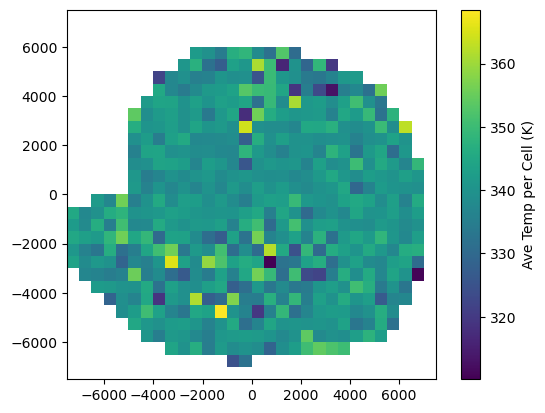

In [14]:
import numpy as np

resolution = hdul[0].data[0][0][0].shape[0]
indices = range(len(temp_data))
bound = np.max(np.abs(particles[indices, :2]))
pixels = np.linspace(-bound, bound, resolution + 1)

H, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels, weights=temp_data)
H_norm, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels)

H /= H_norm

fig, ax = plt.subplots()

# ax.scatter(particles[indices, 0], particles[indices, 1], c=temp_data, s=0.1)
# ax.set(aspect='equal')
p = ax.pcolormesh(x, y, H.T)
ax.set(aspect='equal')
fig.colorbar(p, label='Ave Temp per Cell (K)')